<span style="font-weight:700; font-size:64px; display:block; text-align:center;">
    <span style="color:#43A047;">Res</span><span style="color:#1565C0;">DAG</span>
</span>

<span style="display:block; text-align:center; font-size:22px; color:#E0E0E0; margin-top:8px;">
A modern, GPU-accelerated Reservoir Computing library for PyTorch.
</span>


<img src="images/esn_architecture.png"
     width="1000"
     style="display: block; margin: 0 auto;">


Internal state update:
$$
\begin{equation*}
    \mathbf{x}(n) = f\bigl(\mathbf{W}_{\mathrm{in}}\, \mathbf{u}(n) + \mathbf{W}\, \mathbf{x}(n-1)\bigr),
\end{equation*}
$$

With leak rate:
$$
\begin{equation*}
    \mathbf{x}(n) = (1-\alpha) \mathbf{x}(n-1) + \alpha f\bigl(\mathbf{W}_{\mathrm{in}}\, \mathbf{u}(n) + \mathbf{W}\, \mathbf{x}(n-1)\bigr),
\end{equation*}
$$

Output:
$$
\begin{equation*}
        \mathbf{y}(n) = \mathbf{W}_{\mathrm{out}}\, \mathbf{x}(n),
\end{equation*}
$$

Goal:
$$
\begin{equation*}
    \mathbf{y}(n) \approx \bar{\mathbf{y}}(n),
\end{equation*}
$$




In forecast regime, the desired output is the next step of the target sequence:
$$
\begin{equation*}
    \bar{\mathbf{y}}(n) = \mathbf{u}(n+1).
\end{equation*}
$$


So we split the time series into two parts:
1. Train input: $\mathbf{u}(n) = \mathbf{u}(n)$
2. Train output: $\mathbf{y}(n) = \mathbf{u}(n+1)$


Then the training pipeline is:




<img src="images/esn_pipeline.png"
     width="1000"
     style="display: block; margin: 0 auto;">


<span style="font-weight:700; font-size:64px; display:block; text-align:center;">
    <span style="color:#43A047;">Res</span><span style="color:#1565C0;">DAG</span>
</span>

<span style="display:block; text-align:center; font-size:22px; color:#E0E0E0; margin-top:8px;">
    <span style="color:#66BB6A;">Res</span> = Reservoir 
    &nbsp;&nbsp;|&nbsp;&nbsp;
    <span style="color:#42A5F5;">DAG</span> = Directed Acyclic Graph
</span>

In [ ]:
import resdag as rd
from resdag.training import ESNTrainer

<span style="font-weight:500; font-size:64px; display:block; text-align:center;">
    <span>Built-in models</span>
</span>

In [ ]:
print(rd.models.__all__)

In [ ]:
model = rd.models.classic_esn(
    reservoir_size=300,
    feedback_size=3,
    output_size=3,
    topology="random",
    feedback_initializer="random",
    spectral_radius=0.9,
    leak_rate=1,
    trainable=True,
    readout_alpha=1e-5,
)

In [ ]:
model.summary()

In [ ]:
model.plot_model(
    show_shapes=True,
    show_trainable=True,
    rankdir="TB",
    save_path="model.svg",
    format="svg",
)

<span style="font-weight:500; font-size:64px; display:block; text-align:center;">
    <span>Built-in topologies and initializers</span>
</span>

In [ ]:
rd.init.topology.show_topologies()

In [ ]:
rd.init.input_feedback.show_input_initializers()


<span style="font-weight:500; font-size:64px; display:block; text-align:center;">
    <span>Custom topologies and initializers</span>
</span>

In [ ]:
import networkx as nx
import numpy as np


@rd.init.topology.register_graph_topology("MyTopology", p=0.1, seed=None)
def custom_graph(n, p=0.1, seed=None) -> nx.Graph:
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1, n):
            if np.random.rand() < p:
                G.add_edge(i, j)
    return G

In [ ]:
from resdag.init.input_feedback import InputFeedbackInitializer


# Custom input feedback initializer
@rd.init.input_feedback.register_input_feedback("MyInitializer", scaling=0.5)
class MyInitializer(InputFeedbackInitializer):
    def __init__(self, scaling=1.0):
        self.scaling = scaling
    def initialize(self, weight, **kwargs):
        rows, cols = weight.shape
        weight.data.uniform_(-self.scaling, self.scaling)
        return weight


In [ ]:
rd.init.topology.show_topologies()

In [ ]:
rd.init.input_feedback.show_input_initializers()

<span style="font-weight:500; font-size:64px; display:block; text-align:center;">
    <span>Custom models</span>
</span>

In [47]:
import pytorch_symbolic as ps

inputs = ps.Input(shape=(1, 3))


reservoir = rd.layers.NGReservoir(3, k=10, s=1, p=2)(inputs)

reservoir1 = rd.layers.ESNLayer(
    reservoir_size=500,
    feedback_size=3,
    input_size=0,
    feedback_initializer=("random", {"seed": 42}),
    topology=("erdos_renyi", {"p": 0.15, "seed": 42}),
    spectral_radius=0.8,
    leak_rate=1.0,
    trainable=True,
)(inputs)

concat = rd.layers.Concatenate()(reservoir1, reservoir)

readout1 = rd.layers.CGReadoutLayer(500, 3, bias=True, name="readout1", trainable=True)(
    reservoir1
)

readout = rd.layers.CGReadoutLayer(996, 3, bias=True, name="readout", trainable=True)(
    concat
)

model1 = rd.ESNModel(inputs, [readout1, readout])

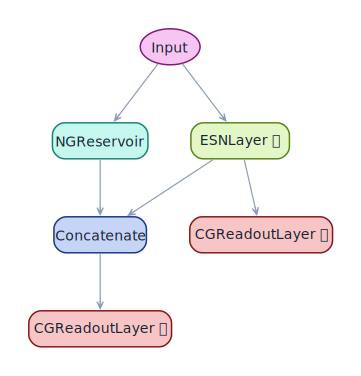

In [48]:
model1.plot_model(show_trainable=True)

<span style="font-weight:500; font-size:64px; display:block; text-align:center;">
    <span>Forecasting</span>
</span>

<span style="font-weight:500; font-size:24px; display:block; text-align:center;">
    <span>Load data</span>
</span>

In [49]:
warmup, train, target, f_warmup, val = rd.utils.data.load_and_prepare(
    "data/Lorenz/Lorenz_1.npy",
    warmup_steps=1000,
    train_steps=10000,
    val_steps=1000,
    discard_steps=1000,
    normalize=True,
    norm_method="minmax",
)

Compatible formats:
- .csv
- .npy
- .npz
- .nc

In [ ]:
warmup.shape

<span style="font-weight:500; font-size:24px; display:block; text-align:center;">
    <span>Training</span>
</span>

In [ ]:
trainer = ESNTrainer(model)
trainer.fit(warmup_inputs=(warmup,), train_inputs=(train,), targets={"output": target})

<span style="font-weight:500; font-size:24px; display:block; text-align:center;">
    <span>Predictions</span>
</span>

In [ ]:
preds = model.forecast(f_warmup, horizon=2000)

In [ ]:
preds.shape

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib widget

s = 0
k = 300

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot the data
ax.plot(preds[s, :k, 0], preds[s, :k, 1], preds[s, :k, 2])
ax.plot(val[s, :k, 0], val[s, :k, 1], val[s, :k, 2])

plt.show()